In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

In [2]:
stocks = ["AAPL", "MSFT", "NVDA", "TSLA"]

data = yf.download(stocks, start="2020-01-01", end="2025-01-01")

[*********************100%***********************]  4 of 4 completed


In [3]:
print(data.head())

Price           Close                                        High              \
Ticker           AAPL        MSFT      NVDA       TSLA       AAPL        MSFT   
Date                                                                            
2020-01-02  72.333893  152.158386  5.970754  28.684000  72.394101  152.262592   
2020-01-03  71.630646  150.263748  5.875187  29.534000  72.389265  151.523684   
2020-01-06  72.201408  150.652191  5.899825  30.102667  72.239942  150.718510   
2020-01-07  71.861847  149.278549  5.971251  31.270666  72.466330  151.258443   
2020-01-08  73.017838  151.656357  5.982451  32.809334  73.318877  152.328960   

Price                                  Low                                   \
Ticker          NVDA       TSLA       AAPL        MSFT      NVDA       TSLA   
Date                                                                          
2020-01-02  5.970754  28.713333  71.091199  149.989032  5.891364  28.114000   
2020-01-03  5.918990  30.266666  71

In [4]:
close_prices = data["Close"]

print(close_prices.head())

Ticker           AAPL        MSFT      NVDA       TSLA
Date                                                  
2020-01-02  72.333893  152.158386  5.970754  28.684000
2020-01-03  71.630646  150.263748  5.875187  29.534000
2020-01-06  72.201408  150.652191  5.899825  30.102667
2020-01-07  71.861847  149.278549  5.971251  31.270666
2020-01-08  73.017838  151.656357  5.982451  32.809334


In [5]:
returns = close_prices.pct_change()

print(returns.head())

Ticker          AAPL      MSFT      NVDA      TSLA
Date                                              
2020-01-02       NaN       NaN       NaN       NaN
2020-01-03 -0.009722 -0.012452 -0.016006  0.029633
2020-01-06  0.007968  0.002585  0.004194  0.019255
2020-01-07 -0.004703 -0.009118  0.012106  0.038801
2020-01-08  0.016086  0.015929  0.001876  0.049205


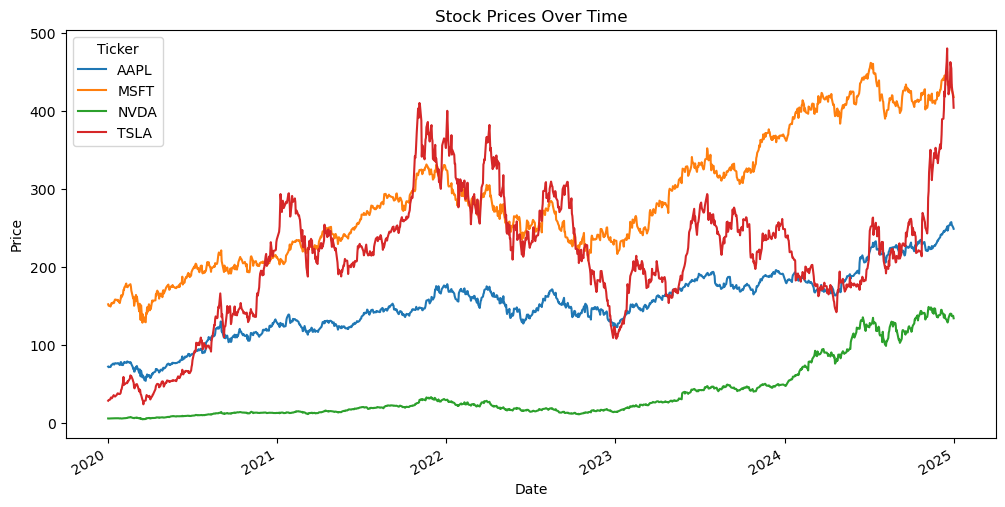

In [6]:
close_prices.plot(figsize=(12,6))

plt.title("Stock Prices Over Time")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

In [7]:
total_return = ((close_prices.iloc[-1] / close_prices.iloc[0]) - 1) * 100

print(total_return)

Ticker
AAPL     244.002224
MSFT     174.359246
NVDA    2148.392986
TSLA    1307.892888
dtype: float64


In [8]:
volatility = returns.std() * np.sqrt(252)

print(volatility)

Ticker
AAPL    0.316786
MSFT    0.304972
NVDA    0.538788
TSLA    0.671815
dtype: float64


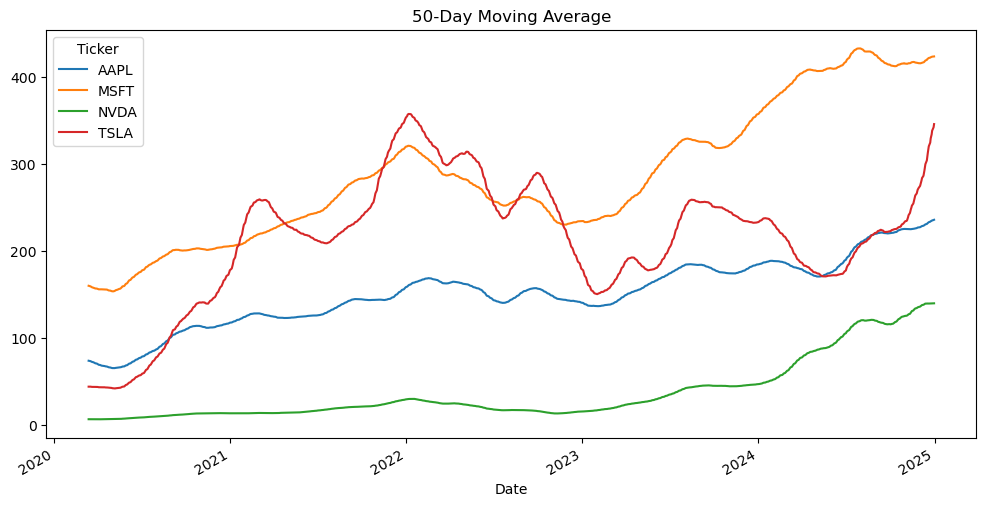

In [9]:
moving_avg = close_prices.rolling(window=50).mean()

moving_avg.plot(figsize=(12,6))

plt.title("50-Day Moving Average")
plt.show()

In [10]:
close_prices.to_excel("close_prices.xlsx")
returns.to_excel("daily_returns.xlsx")

In [11]:
total_return = ((close_prices.iloc[-1] / close_prices.iloc[0]) - 1) * 100

print(total_return)

Ticker
AAPL     244.002224
MSFT     174.359246
NVDA    2148.392986
TSLA    1307.892888
dtype: float64


In [12]:
returns_df = total_return.reset_index()

returns_df.columns = ["Company", "Total Return (%)"]

print(returns_df)

  Company  Total Return (%)
0    AAPL        244.002224
1    MSFT        174.359246
2    NVDA       2148.392986
3    TSLA       1307.892888


In [13]:
returns_df.to_excel("data/total_returns.xlsx", index=False)

OSError: Cannot save file into a non-existent directory: 'data'

In [14]:
returns_df.to_excel("data/total_returns.xlsx", index=False)

In [15]:
volatility = returns.std() * np.sqrt(252)

print(volatility)

Ticker
AAPL    0.316786
MSFT    0.304972
NVDA    0.538788
TSLA    0.671815
dtype: float64


In [16]:
volatility_df = volatility.reset_index()

volatility_df.columns = ["Company", "Volatility"]

print(volatility_df)

  Company  Volatility
0    AAPL    0.316786
1    MSFT    0.304972
2    NVDA    0.538788
3    TSLA    0.671815


In [17]:
volatility_df["Volatility"] = volatility_df["Volatility"].round(2)

In [18]:
volatility_df.to_excel("data/volatility.xlsx", index=False)

In [19]:
moving_avg = close_prices.rolling(window=50).mean()

In [20]:
print(moving_avg.head())

Ticker      AAPL  MSFT  NVDA  TSLA
Date                              
2020-01-02   NaN   NaN   NaN   NaN
2020-01-03   NaN   NaN   NaN   NaN
2020-01-06   NaN   NaN   NaN   NaN
2020-01-07   NaN   NaN   NaN   NaN
2020-01-08   NaN   NaN   NaN   NaN


In [21]:
moving_avg.to_excel("data/moving_average.xlsx")

In [22]:
risk_return_df = pd.merge(
    returns_df,
    volatility_df,
    on="Company"
)

print(risk_return_df)

  Company  Total Return (%)  Volatility
0    AAPL        244.002224        0.32
1    MSFT        174.359246        0.30
2    NVDA       2148.392986        0.54
3    TSLA       1307.892888        0.67


In [23]:
risk_return_df.to_excel("data/risk_return.xlsx", index=False)